# Notebook 02 — Fine-Tuning: Clasificador de Emoción

**Curso:** Minería de Textos | **Proyecto 3** | CUC

---

## Objetivo
Entrenar un clasificador de emoción sobre el corpus de canciones.

**Flujo de este notebook:**
```
1. Cargar corpus desde MongoDB
2. Eliminar duplicados
3. Etiquetar con modelo de sentimiento + keywords (3 niveles)
4. Balancear clases (ratio máximo 3x)
5. Preparar DatasetDict 70/15/15
6. Baseline zero-shot (mayoría de clase)
7. Fine-Tuning DistilBERT + WeightedTrainer + EarlyStopping
8. Evaluar: accuracy, F1 macro, matriz de confusión
9. Etiquetar TODO el corpus con el modelo entrenado → para el RAG
```


In [ ]:
!pip install -q transformers datasets accelerate scikit-learn pymongo python-dotenv torch

In [1]:
import sys, shutil, random
sys.path.append('../app')
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

from app.config import (
    EMOCIONES, ID2EMOCION, EMOCION2ID,
    FINETUNE_MODEL_DIR, RANDOM_SEED, MIN_SAMPLES_PER_CLASS
)
from src.mongo_utils   import mongo_utils
from src.finetuning_utils import finetuning_utils

plt.style.use('dark_background')
print('Librerías cargadas.')

Librerías cargadas.


In [2]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device.upper()}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB')

Dispositivo: CUDA
GPU: NVIDIA GeForce GTX 1650
VRAM: 4.29 GB


## 1. Cargar corpus desde MongoDB

In [5]:
finetuning = finetuning_utils()
db_conexion = mongo_utils()

if db_conexion.verificar_conexion():
    canciones = db_conexion.cargar_canciones()
    print(f'Canciones cargadas: {len(canciones)}')
else:
    canciones = []
    print('ERROR: No se pudo conectar a MongoDB Atlas.')

2026-04-22 20:59:27 | INFO     | mongo_utils | Conectando a MongoDB Atlas | DB: analisisMusical | Col: analisisMusical
2026-04-22 20:59:29 | INFO     | mongo_utils | Conexión verificada correctamente.
2026-04-22 20:59:29 | INFO     | mongo_utils | Cargando canciones | limite=None | solo_con_letra=True
2026-04-22 21:00:32 | INFO     | mongo_utils | Canciones cargadas: 6940
Canciones cargadas: 6940


## 2. Eliminar duplicados

In [6]:
df_antes = len(canciones)

vistos, canciones_limpias = set(), []
for c in canciones:
    clave = (str(c.get('titulo','')).lower().strip(),
             str(c.get('artista','')).lower().strip())
    if clave not in vistos:
        vistos.add(clave)
        canciones_limpias.append(c)

canciones = canciones_limpias
print(f'Antes:              {df_antes}')
print(f'Duplicados removidos: {df_antes - len(canciones)}')
print(f'Después:            {len(canciones)}')

Antes:              6940
Duplicados removidos: 414
Después:            6526


## 3. Etiquetado combinado (modelo de sentimiento + keywords)

El etiquetado usa 3 niveles en orden de precisión:
1. **Keywords estrictas** (umbral 2) → alta precisión
2. **Keywords suaves** (umbral 1) → mayor cobertura para canciones cortas
3. **Modelo de sentimiento multilingüe** → canciones sin señal de keywords


In [8]:
# Paso 1: Keywords estrictas (umbral 2) — alta precisión
dataset_keywords = finetuning.etiquetar_corpus_keywords(canciones)

dist = Counter(d['emocion'] for d in dataset_keywords)
cobertura = len(dataset_keywords)/len(canciones)*100
print(f'Cobertura keywords: {len(dataset_keywords)}/{len(canciones)} ({cobertura:.1f}%)')
print('Distribución:')
for e, c in sorted(dist.items(), key=lambda x: -x[1]):
    print(f'  {e:12s}: {c:5d} ({c/len(dataset_keywords)*100:.1f}%)')

# Paso 2: Ampliar con modelo de sentimiento para canciones sin etiqueta
if cobertura < 80:
    print(f'\nCobertura baja ({cobertura:.1f}%). Ampliando con modelo de sentimiento...')
    titulos_ya = {d['titulo'] for d in dataset_keywords}
    sin_etiqueta = [c for c in canciones if c.get('titulo','') not in titulos_ya]
    nuevos = finetuning.etiquetar_con_modelo_sentimiento(sin_etiqueta, titulos_ya)
    dataset_etiquetado = dataset_keywords + nuevos
    print(f'Nuevas etiquetas: {len(nuevos)}')
else:
    print('Cobertura suficiente. Solo keywords.')
    dataset_etiquetado = dataset_keywords

dist_final = Counter(d['emocion'] for d in dataset_etiquetado)
print(f'\nCobertura final: {len(dataset_etiquetado)}/{len(canciones)} ({len(dataset_etiquetado)/len(canciones)*100:.1f}%)')
print('Distribución final:')
for e, c in sorted(dist_final.items(), key=lambda x: -x[1]):
    print(f'  {e:12s}: {c:5d} ({c/len(dataset_etiquetado)*100:.1f}%)')

2026-04-22 21:01:23 | INFO     | EmotionClassifier | Etiquetando por keywords (6526 canciones)...
2026-04-22 21:01:23 | INFO     | EmotionClassifier | Etiquetadas: 5002 | Sin etiqueta: 1524
2026-04-22 21:01:23 | INFO     | EmotionClassifier | Cobertura: 76.6%
2026-04-22 21:01:23 | INFO     | EmotionClassifier | Distribución: {'amor': 2297, 'nostalgia': 962, 'rabia': 782, 'alegria': 560, 'tristeza': 401}
Cobertura keywords: 5002/6526 (76.6%)
Distribución:
  amor        :  2297 (45.9%)
  nostalgia   :   962 (19.2%)
  rabia       :   782 (15.6%)
  alegria     :   560 (11.2%)
  tristeza    :   401 (8.0%)

Cobertura baja (76.6%). Ampliando con modelo de sentimiento...
2026-04-22 21:01:23 | INFO     | EmotionClassifier | Etiquetando 1464 canciones con modelo de sentimiento...


C:\Users\pmari\OneDrive\Para Revisar\Documentos\Pablo\Cuc\2026\Mineria de Textos\chatbot-musical-inteligente\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-04-22 21:01:44 | INFO     | EmotionClassifier | Cargando modelo de sentimiento multilingüe...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 5565.58it/s]


2026-04-22 21:01:46 | INFO     | EmotionClassifier | Modelo de sentimiento cargado.


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


2026-04-22 21:01:59 | INFO     | EmotionClassifier | Nuevas etiquetas: 1464
2026-04-22 21:01:59 | INFO     | EmotionClassifier | Distribución: {'rabia': 624, 'amor': 516, 'nostalgia': 178, 'tristeza': 75, 'alegria': 71}
Nuevas etiquetas: 1464

Cobertura final: 6466/6526 (99.1%)
Distribución final:
  amor        :  2813 (43.5%)
  rabia       :  1406 (21.7%)
  nostalgia   :  1140 (17.6%)
  alegria     :   631 (9.8%)
  tristeza    :   476 (7.4%)


## 4. Análisis de desbalance y balanceo de clases

Submuestreamos las clases mayoritarias para mantener un ratio máximo de 3x.
Los class weights del WeightedTrainer compensarán el desbalance residual.


In [9]:
dist = Counter(d['emocion'] for d in dataset_etiquetado)
total = len(dataset_etiquetado)

print('DISTRIBUCIÓN Y RATIO DE DESBALANCE')
print('=' * 50)
clase_min = min(dist.values())
clase_max = max(dist.values())
print(f'Clase más pequeña: {clase_min}')
print(f'Clase más grande:  {clase_max}')
print(f'Ratio desbalance:  {clase_max/clase_min:.1f}x')

# Balancear si el ratio supera 3x
if clase_max / clase_min > 3.0:
    print('\nAplicando balanceo (ratio > 3x)...')
    dataset_final = finetuning.balancear_dataset(dataset_etiquetado, ratio_max=3.0)
else:
    print('\nRatio aceptable. No se necesita balanceo.')
    dataset_final = dataset_etiquetado

dist_final = Counter(d['emocion'] for d in dataset_final)
print(f'\nDataset final: {len(dataset_final)} muestras')
print(f'Nuevo ratio:   {max(dist_final.values())/min(dist_final.values()):.1f}x')

DISTRIBUCIÓN Y RATIO DE DESBALANCE
Clase más pequeña: 476
Clase más grande:  2813
Ratio desbalance:  5.9x

Aplicando balanceo (ratio > 3x)...
2026-04-22 21:02:23 | INFO     | EmotionClassifier | Balanceando dataset | clase_min=476 | limite_max=1428
2026-04-22 21:02:23 | INFO     | EmotionClassifier |   tristeza    : 476 (sin cambio)
2026-04-22 21:02:23 | INFO     | EmotionClassifier |   nostalgia   : 1140 (sin cambio)
2026-04-22 21:02:23 | INFO     | EmotionClassifier |   amor        : 2813 → 1428 (submuestreado)
2026-04-22 21:02:23 | INFO     | EmotionClassifier |   alegria     : 631 (sin cambio)
2026-04-22 21:02:23 | INFO     | EmotionClassifier |   rabia       : 1406 (sin cambio)
2026-04-22 21:02:23 | INFO     | EmotionClassifier | Total final: 5081 | Ratio: 3.0x

Dataset final: 5081 muestras
Nuevo ratio:   3.0x


## 5. Preparar splits train / validation / test (70/15/15)

In [10]:
dataset_dict = finetuning.preparar_dataset_hf(dataset_final)
print(dataset_dict)

2026-04-22 21:02:38 | INFO     | EmotionClassifier | Preparando DatasetDict para HuggingFace...
2026-04-22 21:02:38 | INFO     | EmotionClassifier | Clases válidas (>=50): ['alegria', 'amor', 'nostalgia', 'rabia', 'tristeza']
2026-04-22 21:02:38 | INFO     | EmotionClassifier | Total muestras: 5081
2026-04-22 21:02:38 | INFO     | EmotionClassifier | Splits: train=3557 | val=762 | test=762
DatasetDict({
    train: Dataset({
        features: ['texto', 'emocion', 'titulo', 'artista', 'label'],
        num_rows: 3557
    })
    validation: Dataset({
        features: ['texto', 'emocion', 'titulo', 'artista', 'label'],
        num_rows: 762
    })
    test: Dataset({
        features: ['texto', 'emocion', 'titulo', 'artista', 'label'],
        num_rows: 762
    })
})


## 6. Baseline zero-shot (sin fine-tuning)

Predecir siempre la clase más frecuente — baseline naive estándar en clasificación.
Sirve para cuantificar la ganancia real del fine-tuning.


In [11]:
from sklearn.metrics import accuracy_score, f1_score

muestra     = dataset_dict['test'].select(range(min(200, len(dataset_dict['test']))))
labels_real = [ID2EMOCION[l] for l in muestra['label']]

clase_mas_frecuente = Counter(labels_real).most_common(1)[0][0]
preds_zero          = [clase_mas_frecuente] * len(labels_real)

acc_zero = accuracy_score(labels_real, preds_zero)
f1_zero  = f1_score(labels_real, preds_zero, average='macro', zero_division=0)

print(f'BASELINE (mayoría de clase: "{clase_mas_frecuente}")')
print(f'Accuracy: {acc_zero:.4f} | F1 Macro: {f1_zero:.4f}')
print('Referencia para comparar con el modelo fine-tuneado.')

BASELINE (mayoría de clase: "amor")
Accuracy: 0.3250 | F1 Macro: 0.0981
Referencia para comparar con el modelo fine-tuneado.


## 7. Fine-Tuning con WeightedTrainer + EarlyStopping

- **WeightedTrainer**: `CrossEntropyLoss` ponderado por class weights
- **EarlyStopping**: se detiene si F1 no mejora en 2 épocas consecutivas
- **warmup_ratio=0.1**: calentamiento gradual del learning rate


In [12]:
# Eliminar modelo anterior
if Path(FINETUNE_MODEL_DIR).exists():
    shutil.rmtree(FINETUNE_MODEL_DIR)
    print(f'Modelo anterior eliminado: {FINETUNE_MODEL_DIR}')

num_labels = len(set(dataset_dict['train']['label']))
print(f'Clases: {num_labels}')
trainer, tokenizer, model = finetuning.entrenar(dataset_dict, num_labels=num_labels)

Modelo anterior eliminado: C:\Users\pmari\OneDrive\Para Revisar\Documentos\GitHub\chatbot-musical-inteligente\models\clasificador_emocion
Clases: 5
2026-04-22 21:03:41 | INFO     | EmotionClassifier | Iniciando fine-tuning de distilbert-base-multilingual-cased
2026-04-22 21:03:41 | INFO     | EmotionClassifier | Class weights:
2026-04-22 21:03:41 | INFO     | EmotionClassifier |   alegria     : 1.6430
2026-04-22 21:03:41 | INFO     | EmotionClassifier |   tristeza    : 2.0210
2026-04-22 21:03:41 | INFO     | EmotionClassifier |   amor        : 0.7215
2026-04-22 21:03:41 | INFO     | EmotionClassifier |   rabia       : 0.7289
2026-04-22 21:03:41 | INFO     | EmotionClassifier |   nostalgia   : 0.8783


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3613.32it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 762/762 [00:00<00:00, 5624.41 examples/s]


2026-04-22 21:03:47 | INFO     | EmotionClassifier | Dispositivo: GPU | Épocas: 7 | Batch: 16 | LR: 2e-05


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


2026-04-22 21:03:49 | INFO     | EmotionClassifier | Entrenando...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.551397,1.462037,0.321522,0.271895
2,1.072507,1.052807,0.599738,0.578802
3,0.723210,0.913177,0.640420,0.634291
4,0.549079,0.861223,0.702100,0.693800
5,0.358772,0.848900,0.728346,0.724865
6,0.295478,0.858866,0.737533,0.738638
7,0.212248,0.888798,0.723097,0.723012


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.10s/it]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.30s/it]


2026-04-22 23:38:35 | INFO     | EmotionClassifier | Modelo guardado en C:\Users\pmari\OneDrive\Para Revisar\Documentos\GitHub\chatbot-musical-inteligente\models\clasificador_emocion


## 8. Evaluación en test set

In [13]:
metricas = finetuning.evaluar(trainer, dataset_dict, tokenizer)

print(f'\nCOMPARACIÓN BASELINE vs FINE-TUNED:')
print(f'  Baseline   → Accuracy: {acc_zero:.4f} | F1: {f1_zero:.4f}')
print(f'  Fine-tuned → Accuracy: {metricas["accuracy"]:.4f} | F1: {metricas["f1_macro"]:.4f}')
print(f'  Ganancia   → +{metricas["accuracy"]-acc_zero:.4f} accuracy | +{metricas["f1_macro"]-f1_zero:.4f} F1')

2026-04-22 23:40:06 | INFO     | EmotionClassifier | Evaluando modelo en test set...


Map: 100%|██████████| 762/762 [00:00<00:00, 4790.52 examples/s]


2026-04-22 23:41:59 | INFO     | EmotionClassifier | Accuracy: 0.7572 | F1 Macro: 0.7475
2026-04-22 23:41:59 | INFO     | EmotionClassifier | Métricas guardadas en resultados/metricas.json

COMPARACIÓN BASELINE vs FINE-TUNED:
  Baseline   → Accuracy: 0.3250 | F1: 0.0981
  Fine-tuned → Accuracy: 0.7572 | F1: 0.7475
  Ganancia   → +0.4322 accuracy | +0.6494 F1


## 9. Matriz de confusión

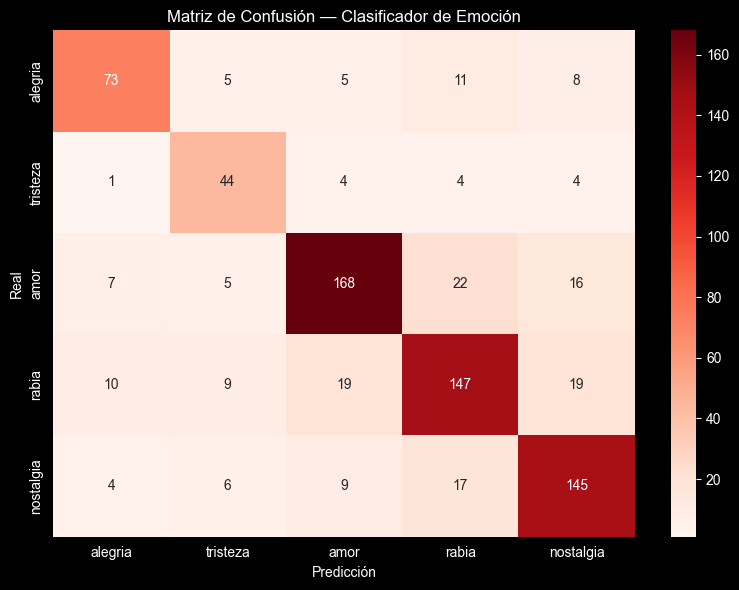

Matriz guardada en resultados/confusion_matrix.png


In [14]:
cm     = np.array(metricas['confusion_matrix'])
clases = [ID2EMOCION[i] for i in range(len(cm))]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=clases, yticklabels=clases)
plt.title('Matriz de Confusión — Clasificador de Emoción', color='white')
plt.xlabel('Predicción', color='white')
plt.ylabel('Real', color='white')
plt.tight_layout()
plt.savefig('../resultados/confusion_matrix.png', dpi=120,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('Matriz guardada en resultados/confusion_matrix.png')

## 10. Prueba del clasificador fine-tuneado

In [15]:
frases_prueba = [
    'Me duele el corazón, no puedo dejar de llorar por ti',
    'Bailando hasta el amanecer, la vida es una fiesta',
    'Te amo con todo mi ser, eres mi razón de existir',
    'Te odio, me traicionaste, nunca te voy a perdonar',
    'Recuerdo aquellos tiempos cuando éramos felices juntos',
]

print('PRUEBA DEL CLASIFICADOR FINE-TUNEADO')
print('=' * 60)
for frase in frases_prueba:
    resultado = finetuning.predecir_emocion(frase)
    if resultado:
        print(f'Emoción: {resultado["emocion"]:12s} ({resultado["score"]:.2%}) → "{frase[:55]}..."')

PRUEBA DEL CLASIFICADOR FINE-TUNEADO


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3002.94it/s]


2026-04-22 23:43:36 | INFO     | EmotionClassifier | Clasificador cargado para inferencia.
Emoción: tristeza     (84.68%) → "Me duele el corazón, no puedo dejar de llorar por ti..."
Emoción: alegria      (37.53%) → "Bailando hasta el amanecer, la vida es una fiesta..."
Emoción: tristeza     (49.55%) → "Te amo con todo mi ser, eres mi razón de existir..."
Emoción: tristeza     (48.61%) → "Te odio, me traicionaste, nunca te voy a perdonar..."
Emoción: amor         (58.26%) → "Recuerdo aquellos tiempos cuando éramos felices juntos..."


## 11. Etiquetar TODO el corpus con el modelo fine-tuneado

Este es el paso que conecta el fine-tuning con el RAG.
El clasificador entrenado asigna una emoción a CADA canción del corpus.
El resultado se cachea en `data/embeddings_cache/corpus_con_emociones.pkl`
y el Notebook 03 lo usa para construir el índice FAISS.


In [16]:
# Etiquetar todo el corpus original (sin duplicados) con el clasificador
corpus_etiquetado = finetuning.etiquetar_corpus_con_modelo(canciones, forzar=True)

print(f'\nCorpus listo para el RAG: {len(corpus_etiquetado)} canciones etiquetadas')
print('Ahora ejecuta el Notebook 03 para construir el índice FAISS.')

2026-04-22 23:45:06 | INFO     | EmotionClassifier | Cargando clasificador desde C:\Users\pmari\OneDrive\Para Revisar\Documentos\GitHub\chatbot-musical-inteligente\models\clasificador_emocion...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3496.74it/s]


2026-04-22 23:45:07 | INFO     | EmotionClassifier | Clasificando 6526 canciones en batches de 64...
2026-04-22 23:45:08 | INFO     | EmotionClassifier |   Procesadas: 64/6526
2026-04-22 23:45:22 | INFO     | EmotionClassifier |   Procesadas: 704/6526
2026-04-22 23:45:38 | INFO     | EmotionClassifier |   Procesadas: 1344/6526
2026-04-22 23:45:52 | INFO     | EmotionClassifier |   Procesadas: 1984/6526
2026-04-22 23:46:05 | INFO     | EmotionClassifier |   Procesadas: 2624/6526
2026-04-22 23:46:19 | INFO     | EmotionClassifier |   Procesadas: 3264/6526
2026-04-22 23:46:33 | INFO     | EmotionClassifier |   Procesadas: 3904/6526
2026-04-22 23:46:47 | INFO     | EmotionClassifier |   Procesadas: 4544/6526
2026-04-22 23:47:01 | INFO     | EmotionClassifier |   Procesadas: 5184/6526
2026-04-22 23:47:16 | INFO     | EmotionClassifier |   Procesadas: 5824/6526
2026-04-22 23:47:31 | INFO     | EmotionClassifier |   Procesadas: 6464/6526
2026-04-22 23:47:33 | INFO     | EmotionClassifier | Co